In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

# Load the data
df = pd.read_csv("students.csv")
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("--- Data Exploration ---")
print(df.head())
print("\nColumn Data Types:")
print(df.dtypes)
print("\nSummary Statistics:")
print(df.describe())

--- Data Exploration ---
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Column Data Types:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary Statistics:
            math    science    english  

In [5]:
# Count pass/fail
pass_counts = df['passed'].value_counts()
print(f"Passed: {pass_counts[1]}, Failed: {pass_counts[0]}")

# Average score per subject for pass vs fail
pass_avg = df[df['passed'] == 1][subject_cols].mean()
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print("\nAverage scores for Passing students:\n", pass_avg)
print("\nAverage scores for Failing students:\n", fail_avg)

# Highest overall average student
df['overall_avg'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['overall_avg'].idxmax()]
print(f"\nStudent with highest average: {top_student['name']} ({top_student['overall_avg']:.2f})")

Passed: 9, Failed: 6

Average scores for Passing students:
 math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Average scores for Failing students:
 math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64

Student with highest average: Diana (94.00)


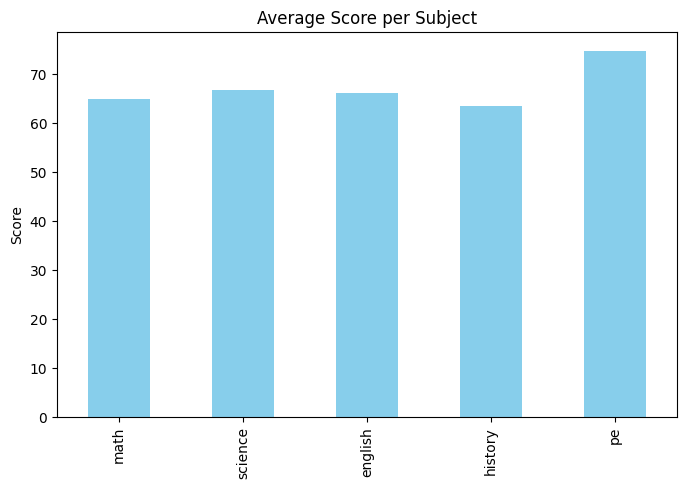

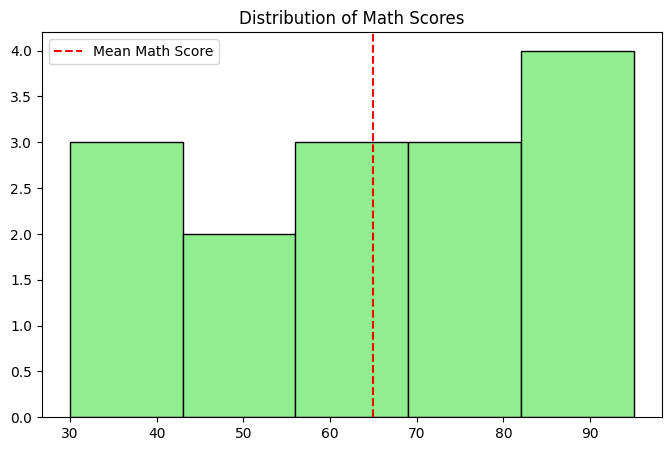

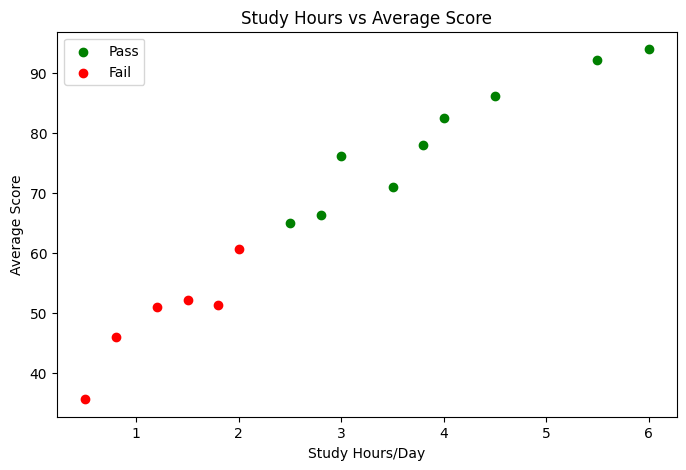

C:\Users\Net\AppData\Local\Temp\ipykernel_10684\2176109163.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attn, fail_attn], labels=['Pass', 'Fail'])


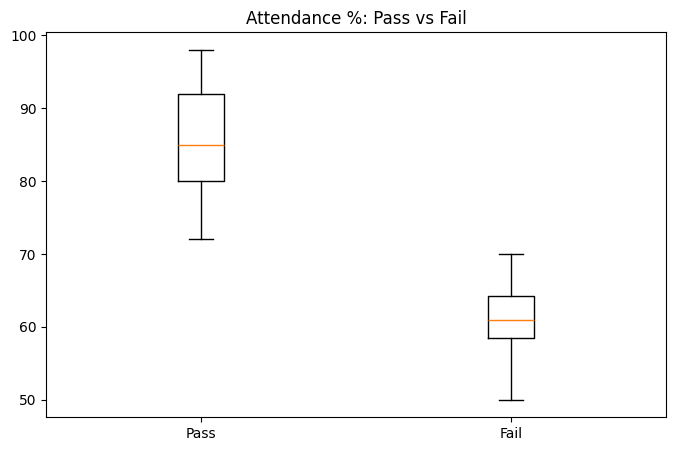

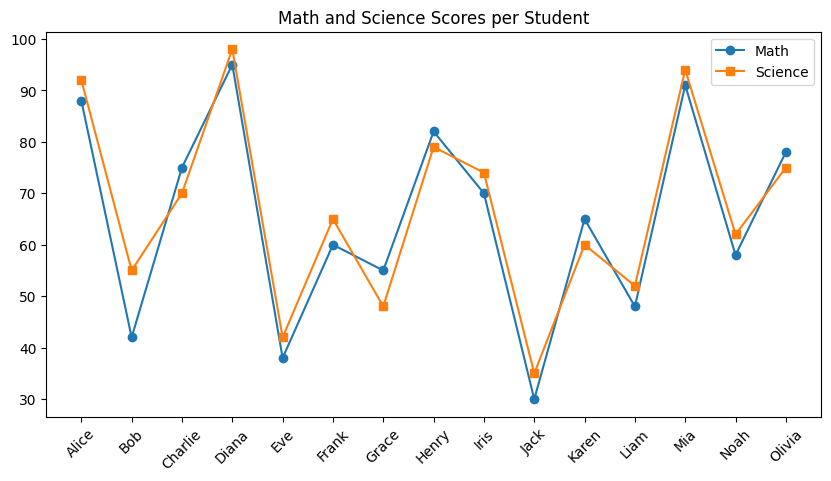

In [6]:
# Adding avg_score column as requested
df['avg_score'] = df[subject_cols].mean(axis=1)

# Plot 1: Bar Chart
plt.figure(figsize=(8, 5))
df[subject_cols].mean().plot(kind='bar', color='skyblue')
plt.title("Average Score per Subject")
plt.ylabel("Score")
plt.savefig("plot1_bar.png")
plt.show()

# Plot 2: Histogram
plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, color='lightgreen', edgecolor='black')
plt.axvline(df['math'].mean(), color='red', linestyle='dashed', label='Mean Math Score')
plt.title("Distribution of Math Scores")
plt.legend()
plt.savefig("plot2_hist.png")
plt.show()

# Plot 3: Scatter Plot
plt.figure(figsize=(8, 5))
for status, color in zip([1, 0], ['green', 'red']):
    subset = df[df['passed'] == status]
    plt.scatter(subset['study_hours_per_day'], subset['avg_score'], color=color, label='Pass' if status==1 else 'Fail')
plt.xlabel("Study Hours/Day")
plt.ylabel("Average Score")
plt.title("Study Hours vs Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

# Plot 4: Box Plot
plt.figure(figsize=(8, 5))
pass_attn = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attn = df[df['passed'] == 0]['attendance_pct'].tolist()
plt.boxplot([pass_attn, fail_attn], labels=['Pass', 'Fail'])
plt.title("Attendance %: Pass vs Fail")
plt.savefig("plot4_box.png")
plt.show()

# Plot 5: Line Plot
plt.figure(figsize=(10, 5))
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', label='Science')
plt.xticks(rotation=45)
plt.title("Math and Science Scores per Student")
plt.legend()
plt.savefig("plot5_line.png")
plt.show()

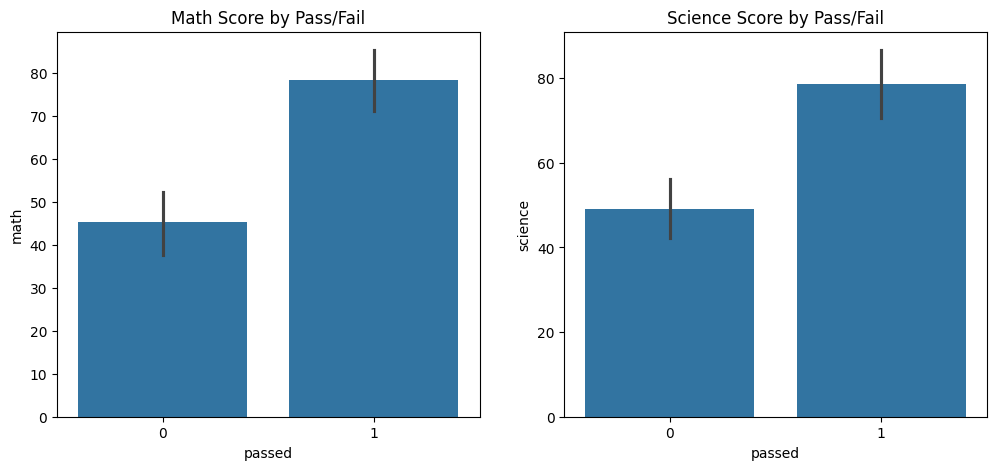

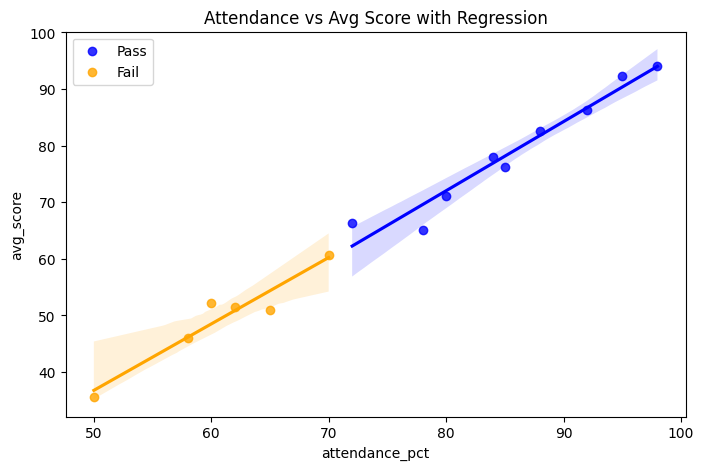

In [8]:
# Plot 6: Seaborn Bar Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=df, x='passed', y='math', ax=ax[0])
ax[0].set_title("Math Score by Pass/Fail")
sns.barplot(data=df, x='passed', y='science', ax=ax[1])
ax[1].set_title("Science Score by Pass/Fail")
plt.savefig("plot6_seaborn_bar.png")
plt.show()

# Plot 7: Seaborn Scatter + Regression
plt.figure(figsize=(8, 5))
sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', label='Pass', color='blue')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', label='Fail', color='orange')
plt.title("Attendance vs Avg Score with Regression")
plt.legend()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

# Comparison Comment
# Seaborn is much better for statistical plotting because it handles groupings and 
# regression lines automatically. Matplotlib requires more manual code for things 
# like legends and coloring by categories, but it offers more granular control.

Training Accuracy: 100.00%
Test Accuracy: 100.00%

Test Set Results:
Jack: Actual=0, Predicted=0 ✅
Liam: Actual=0, Predicted=0 ✅
Alice: Actual=1, Predicted=1 ✅


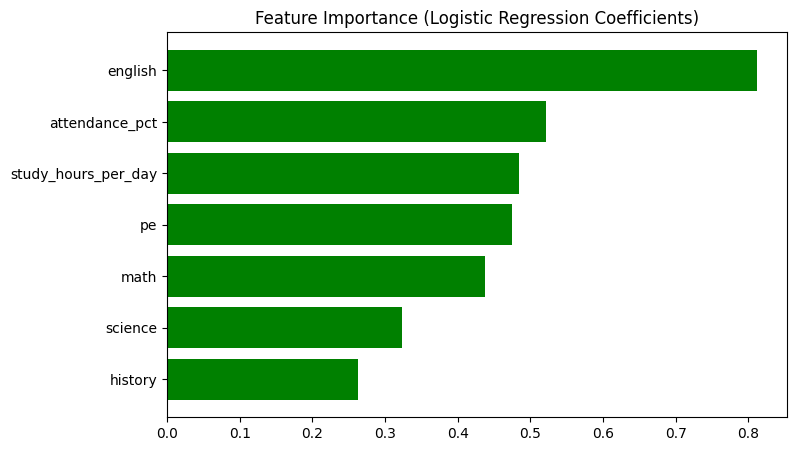

In [9]:
# Prepare Data
X = df[['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Accuracy
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
print(f"Training Accuracy: {train_acc:.2%}")
print(f"Test Accuracy: {test_acc:.2%}")

# Predictions for test set
preds = model.predict(X_test_scaled)
print("\nTest Set Results:")
for idx, p, actual in zip(X_test.index, preds, y_test):
    name = df.loc[idx, 'name']
    emoji = "✅" if p == actual else "❌"
    print(f"{name}: Actual={actual}, Predicted={p} {emoji}")

# Feature Importance
importance = model.coef_[0]
feat_names = X.columns
sorted_idx = np.argsort(np.abs(importance))

plt.figure(figsize=(8, 5))
plt.barh(feat_names[sorted_idx], importance[sorted_idx], color=['red' if x < 0 else 'green' for x in importance[sorted_idx]])
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.savefig("feature_importance.png")
plt.show()

In [10]:
# Predict for a new student
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
new_scaled = scaler.transform(new_student)
pred_class = model.predict(new_scaled)[0]
prob = model.predict_proba(new_scaled)[0]

print(f"Prediction for New Student: {'Pass' if pred_class == 1 else 'Fail'}")
print(f"Probability: Pass={prob[1]:.2f}, Fail={prob[0]:.2f}")

Prediction for New Student: Pass
Probability: Pass=0.91, Fail=0.09


C:\Users\Net\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
